# Stanford CME 241 (Winter 2026) - Assignment 1

**Due: Friday, January 23 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):*
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
from rl.markov_process import FiniteMarkovProcess
from rl.distribution import Categorical, Constant
from rl.markov_decision_process import FiniteMarkovDecisionProcess
import matplotlib.pyplot as plt
from rich import print as rich_print
from rl.dynamic_programming import value_iteration_result

## Question 1: Snakes and Ladders (Led by ______)

In the classic childhood game of Snakes and Ladders, all players start to the left of square 1 (call this position 0) and roll a 6-sided die to represent the number of squares they can move forward. The goal is to reach square 100 as quickly as possible. Landing on the bottom rung of a ladder allows for an automatic free-pass to climb, e.g. square 4 sends you directly to 14; whereas landing on a snake's head forces one to slide all the way to the tail, e.g. square 34 sends you to 6. Note, this game can be viewed as a Markov Process, where the outcome is only depedent on the current state and not the prior trajectory. In this question, we will ask you to both formally describe the Markov Process that describes this game, followed by coding up a version of the game to get familiar with the RL-book libraries.


### Problem Statement

How can we model this problem with a Markov Process?

---

### Subquestions

#### Part (A): MDP Modeling

Formalize the state space of the Snakes and Ladders game. Don't forget to specify the terminal state!

---

#### Part (B): Transition Probabilities

Write out the structure of the transition probabilities. Feel free to abbreviate all squares that do not have a snake or ladder.

---

#### Part (C): Modeling the Game

Code up a `transition_map: Transition[S]` data structure to represent the transition probabilities of the Snakes and Ladders Markov Process so you can model the game as an instance of `FiniteMarkovProcess`. Use the `traces` method to create sampling traces, and plot the graph of the distribution of time steps to finish the game. Use the image provided for the locations of the snakes and ladders.

https://drive.google.com/file/d/1yhP242sG092Ico_WOPKrUp8jVJHbuGHH/view?usp=sharing

---

### Part (A) Answer
The states $S=\{0, ..., 100\}$ of which the non-terminal states are: $N = \{0, ..., 99\}$ and the terminal states are: $T=\{100\}$

### Part (B) Answer
By inspecting the picture linked to in part C we have the subset of special states (states where theres a ladder or a snake): $SS=\{1, 4, 8, 21, 28, 32, 36, 48, 50, 62, 71, 80, 88, 95, 97\}$. Following the same notation as in Lecture 2 slide 16 and letting $x\in{1, ..., 6}$ for all states we have:

$$
\begin{align*}
\{\\
1: \text{Categorical}({39+x: \frac{1}{6}}),\\
4: \text{Categorical}({15+x: \frac{1}{6}}),\\
8: \text{Categorical}({10+x: \frac{1}{6}}),\\
21: \text{Categorical}({42+x: \frac{1}{6}}),\\
28: \text{Categorical}({76+x: \frac{1}{6}}),\\
32: \text{Categorical}({10+x: \frac{1}{6}}),\\
36: \text{Categorical}({6+x: \frac{1}{6}}),\\
48: \text{Categorical}({26+x: \frac{1}{6}}),\\
50: \text{Categorical}({67+x: \frac{1}{6}}),\\
62: \text{Categorical}({18+x: \frac{1}{6}}),\\
71: \text{Categorical}({92+x: \frac{1}{6}}),\\
80: \text{Categorical}({100: 1}),\\
88: \text{Categorical}({24+x: \frac{1}{6}}),\\
95: \text{Categorical}({56+x: \frac{1}{6}}),\\
97: \text{Categorical}({78+x: \frac{1}{6}})\\
\}
\end{align*}
$$

For all other states $s\in S\backslash SS$ we have:
$$
\begin{align*}
s: \text{Categorical}({39+x: \frac{1}{6}})\\
\end{align*}
$$

### Part (C) Answer
**Note:** in the implementation below we acutally have terminal states 100, 101, 102, 103, 104, 105, since I am not handling the case when a player rolls over 100. This does not make any material difference as we can view {100, 101, 102, 103, 104, 105} all as the same state. This also makes the code somewhat cleaner.

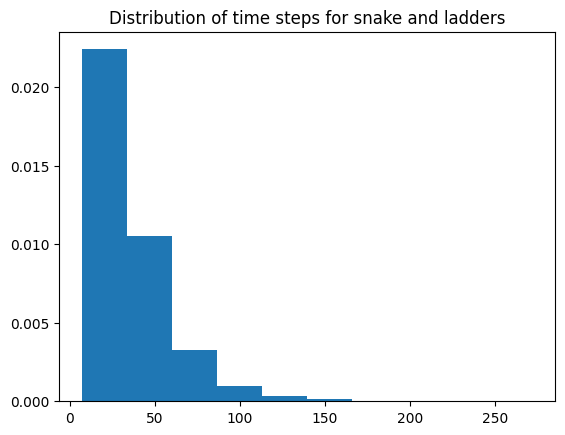

In [2]:
all_states = {i for i in range(100)}

# This maps the special states (states where there is a ladder or a snake) to which state it leads to.
special_states_map = {
    1: 38, 
    4: 14, 
    8: 10, 
    21: 42, 
    28: 76, 
    32: 10, 
    36: 6, 
    48: 26, 
    50: 67, 
    62: 18, 
    71: 92, 
    80: 99, 
    88: 24, 
    95: 56, 
    97: 78
}

normal_states = all_states - special_states_map.keys()
transition_map = {
    # These are the normal states
    **{x: Categorical({**{i: 1/6 for i in [x+1, x+2, x+3, x+4, x+5, x+6]}}) for x in normal_states},
    # These are the special states
    **{state: Categorical({**{i: 1/6 for i in [new_state+1, new_state+2, new_state+3, new_state+4, new_state+5, new_state+6]}}) for state, new_state in special_states_map.items()},
}

markov_process = FiniteMarkovProcess(transition_map)
traces = markov_process.traces(Constant(markov_process.non_terminal_states[0]))

time_steps_dist = []
n = 10_000
for i in range(n):
    trace = next(traces)
    time_steps_dist.append(len(list(trace)))

plt.hist(time_steps_dist, density=True)
plt.title("Distribution of time steps for snake and ladders")
plt.show()

## Question 2: Markov Decision Processes (Led by ______)

Consider an MDP with an infinite set of states ${S} = \{1,2,3,\ldots \}$. The start state is $s=1$. Each state $s$ allows a continuous set of actions $a \in [0,1]$. The transition probabilities are given by:
$$\mathbb{P}[s+1 \mid s, a] = a, \mathbb{P}[s \mid s, a] = 1 - a \text{ for all } s \in S \text{ for all } a \in [0,1]$$
For all states $s \in {S}$ and actions $a \in [0,1]$, transitioning from $s$ to $s+1$ results in a reward of $1-a$ and transitioning from $s$ to $s$ results in a reward of $1+a$. The discount factor $\gamma=0.5$.

### Problem Statement

How can we derive a mathematical formulation for the value function and the optimal policy? And how do those functions change when we modify the action space?

---

### Subquestions

#### Part (A): Optimal Value Function  

Using the MDP Bellman Optimality Equation, calculate the Optimal Value Function $V^*(s)$ for all $s \in {S}$. Given $V^*(s)$, what is the optimal action, $a^*$, that maximizes the optimal value function?

---

#### Part (B): Optimal Policy  

Calculate an Optimal Deterministic Policy $\pi^*(s)$ for all $s \in {S}$.

---

#### Part (C): Changing the Action Space  

Let's assume that we modify the action space such that instead of $a \in [0,1]$ for all states, we restrict the action space to $a \in \left[0,\frac{1}{s}\right]$ for state $s$. This means that higher states have more restricted action spaces. How does this constraint affect:

- The form of the Bellman optimality equation?
- The optimal value function, $V^*(s)$?
- The structure of the optimal policy, $\pi^*(s)$?

---

## Part (A): Optimal Value Function

The expected immediate reward is
$$
\bar r(a) = a(1-a) + (1-a)(1+a).
$$

Compute:
$$
a(1-a)=a-a^2, \qquad (1-a)(1+a)=1-a^2,
$$
so
$$
\bar r(a)=1+a-2a^2.
$$

The Bellman optimality equation is
$$
V^*(s)=\max_{a\in A_s}\Big[\bar r(a)+\gamma\big(aV^*(s+1)+(1-a)V^*(s)\big)\Big].
$$

Substitute $\bar r(a)=1+a-2a^2$ and $\gamma=\tfrac12$:
$$
V^*(s)=\max_{a\in A_s}\Big[1+a-2a^2+\tfrac12\big(aV^*(s+1)+(1-a)V^*(s)\big)\Big].
$$

Rearranging,
$$
\tfrac12(1+a)V^*(s)
=\max_{a\in A_s}\Big[1+a-2a^2+\tfrac12 aV^*(s+1)\Big],
$$
or equivalently,
$$
V^*(s)
=\max_{a\in A_s}\frac{2(1+a-2a^2)+aV^*(s+1)}{1+a}.
$$

Solving for $A_s=[0,1]$, since the MDP is state-homogeneous, $V^*(s)=V^*$ for all $s$. Then
$$
V^*=\max_{a\in[0,1]}\Big[1+a-2a^2+\tfrac12 V^*\Big],
$$
which implies
$$
\tfrac12 V^*=\max_{a\in[0,1]}(1+a-2a^2).
$$

Maximize $f(a)=1+a-2a^2$:
$$
f'(a)=1-4a=0 \;\Rightarrow\; a^*=\tfrac14,
$$
and $f''(a)=-4<0$, so this is a maximum.

Evaluate:
$$
1+\tfrac14-2\cdot\tfrac1{16}=\tfrac98.
$$

Hence,
$$
V^*=\tfrac94.
$$

$$
\boxed{
V^*(s)=\tfrac94 \;\; \forall s,
\qquad
\pi^*(s)=\tfrac14.
}
$$


### Part (B) Answer


From Part (A), the maximizing action is the same at every state (the problem is state-homogeneous with action set $[0,1]$), and we found
$$
a^*=\tfrac14.
$$

Therefore an optimal deterministic policy is constant across states:
$$
\pi^*(s)=\tfrac14 \quad \text{for all } s\in\{1,2,3,\dots\}.
$$


### Part (C) Answer

With the state-dependent constraint, the Bellman optimality equation becomes
$$
V^*(s)=\max_{0\le a\le 1/s}\Big[1+a-2a^2+\tfrac12\big(aV^*(s+1)+(1-a)V^*(s)\big)\Big].
$$

Rearrange by moving $\tfrac12(1-a)V^*(s)$ to the left:
$$
V^*(s)-\tfrac12(1-a)V^*(s)=\max_{0\le a\le 1/s}\Big[1+a-2a^2+\tfrac12 aV^*(s+1)\Big].
$$
Since $V^*(s)-\tfrac12(1-a)V^*(s)=\tfrac12(1+a)V^*(s)$, we get the equivalent form
$$
\tfrac12(1+a)V^*(s)=\max_{0\le a\le 1/s}\Big[1+a-2a^2+\tfrac12 aV^*(s+1)\Big],
$$
or
$$
V^*(s)=\max_{0\le a\le 1/s}\frac{2(1+a-2a^2)+aV^*(s+1)}{1+a}.
$$

To characterize the optimal action, fix $s$ and write $W=V^*(s+1)$. Define
$$
F(a;W)=\frac{2(1+a-2a^2)+aW}{1+a}, \qquad 0\le a\le \tfrac1s.
$$
An interior maximizer satisfies $F'(a;W)=0$, which simplifies to
$$
4a^2+8a-W=0.
$$
Taking the nonnegative root gives the unconstrained maximizer
$$
a_{\text{uncon}}(s)= -1+\tfrac12\sqrt{4+V^*(s+1)}.
$$
Imposing the constraint $a\le 1/s$ yields the optimal policy
$$
\pi^*(s)=a^*(s)=\min\left\{\tfrac1s,\; -1+\tfrac12\sqrt{4+V^*(s+1)}\right\}.
$$

Because $1/s\to 0$ as $s\to\infty$, for large $s$ the action is forced near $0$. If $a=0$, the process stays at $s$ with reward $1$ forever, so
$$
V = 1+\tfrac12 V \quad \Rightarrow \quad V=2.
$$
Hence,
$$
V^*(s)\to 2 \quad \text{as } s\to\infty.
$$

When the constraint binds (i.e., $a^*(s)=1/s$), substituting $a=1/s$ into the rearranged form gives an explicit recursion:
$$
V^*(s)=\frac{V^*(s+1)+2s+2-\tfrac4s}{s+1}.
$$

So, relative to Parts (A,B): the Bellman equation is the same but the maximization set shrinks with $s$, $V^*(s)$ is no longer constant and decreases toward $2$, and the optimal policy is state-dependent and equals the unconstrained optimizer when feasible, otherwise it saturates at $1/s$.


## Question 3: Frog in a Pond (Led by ______)

Consider an array of $n+1$ lilypads on a pond, numbered $0$ to $n$. A frog sits on a lilypad other than the lilypads numbered $0$ or $n$. When on lilypad $i$ ($1 \leq i \leq n-1$), the frog can croak one of two sounds: **A** or **B**.

- If it croaks **A** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to lilypad $i-1$ with probability $\frac{i}{n}$.
  - It is thrown to lilypad $i+1$ with probability $\frac{n-i}{n}$.
  
- If it croaks **B** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to one of the lilypads $0, \ldots, i-1, i+1, \ldots, n$ with uniform probability $\frac{1}{n}$.

A snake, perched on lilypad $0$, will eat the frog if it lands on lilypad $0$. The frog can escape the pond (and hence, escape the snake!) if it lands on lilypad $n$.

### Problem Statement

What should the frog croak when on each of the lilypads $1, 2, \ldots, n-1$, in order to maximize the probability of escaping the pond (i.e., reaching lilypad $n$ before reaching lilypad $0$)?

Although there are multiple ways to solve this problem, we aim to solve it by modeling it as a **Markov Decision Process (MDP)** and identifying the **Optimal Policy**.

---

### Subquestions

#### Part (A): MDP Modeling

Express the frog-escape problem as an MDP using clear mathematical notation by defining the following components:

- **State Space**: Define the possible states of the MDP.
- **Action Space**: Specify the actions available to the frog at each state.
- **Transition Function**: Describe the probabilities of transitioning between states for each action.
- **Reward Function**: Specify the reward associated with the states and transitions.

---

#### Part (B): Python Implementation

There is starter code below to solve this problem programatically. Fill in each of the $6$ `TODO` areas in the code. As a reference for the transition probabilities and rewards, you can make use of the example in slide 16/31 from the following slide deck: https://github.com/coverdrive/technical-documents/blob/master/finance/cme241/Tour-MP.pdf.

Write Python code that:

- Models this MDP.
- Solves the **Optimal Value Function** and the **Optimal Policy**.

Feel free to use/adapt code from the textbook. Note, there are other libraries that are needed to actually run this code, so running it will not do anything. Just fill in the code so that it could run assuming that the other libraries are present.

---

#### Part (C): Visualization and Analysis

What patterns do you observe for the **Optimal Policy** as you vary $n$ from $3$ to $25$? When the frog is on lilypad $13$ (with $25$ total), what action should the frog take? Is this action different than the action the frog should take if it is on lilypad $1$?

---

### Part (A) Answer

#### State Space:  

$S = \{0, ..., n\}$, with terminal states: $T= \{0, n\}$ and non-terminal states $N = \{1, ..., n-1\}$

#### Action Space:  
The action space denoted by $AS$ is:
$AS = \{A, B\}$

#### Transition Function:  
The transistion function is a function $P:N \times A \times S \to [0,1]$ and defined by:

$$
P(s, a, s') = 
\begin{cases}
P(i, A, i+1) = \frac{n-i}{n}, \forall i \in N\\
P(i, A, i-1) = \frac{i}{n}, \forall i \in N\\
P(i, B, i') = \frac{1}{n}, \forall i \in N, i' \in S \backslash \{i\}\\
\end{cases}
$$

#### Reward Function:  
If we define the reward in the to be $1$ in state $n$ (reward for escaping) and $-1$ in state $0$ (reward for being eaten) and $0$ elsewhere we get that the reward transition function $R_T:N\times AS \times S \to \mathbb{R}$ is given by:
$$
R_T(s, a, s')=
\begin{cases}
R_T(1, A, 0) = -1\\
R_T(n-1, A, n) = 1\\
R_T(i, B, 0) = -1, \forall i \in N\\
R_T(i, B, n) = 1, \forall i \in N\\
0, \text{otherwise}
\end{cases}
$$


and the reward function $R:N\times A \to \mathbb{R}$ is given by:
$$
R(s, a) = 
\begin{cases}
R(1, A) = - \frac{1}{n} \\
R(n-1, A) = \frac{1}{n} \\
R(i, B) = 0, \forall i \in N\\
0, \text{otherwise}
\end{cases}
$$

### Part (B) Answer

The output below from the direct bellman function and the optimal value function from the built-in `value_iteration_result` function. These coincide nicely. This function also gives the optimal policy reported below.

In [3]:
MDPRefined = dict

def get_lily_pads_mdp(n: int) -> MDPRefined:
    data = {
        i: {
            'A': {
                i - 1: (n-i)/n, # TODO: fill in with the correct transition probabilities
                i + 1: i/n, # TODO: fill in with the correct transition probabilities
            },
            'B': {
                **{j: 1/n for j in list(range(i)) + list(range(i+1, n+1))}, # TODO: fill in with the correct transition probabilities
            }
        } for i in range(1, n)
    }
    data[0] = {'A': {0: 1}, 'B': {0: 1}} # TODO: this is the initial state, so what would be the correct transition probabilities?
    data[n] = {'A': {n: 1}, 'B': {n: 1}} # TODO: similarly, this is the terminal state, so what would be the correct transition probabilities?
    gamma = 1.0
    # return MDPRefined(data, gamma)
    return MDPRefined(data=data, gamma=gamma)

class MDPFrogPond():
    def __init__(self, data: MDPRefined, gamma: float, n: int):
        self.n = n
        self.data = data
        self.gamma = gamma
        def reward(target: int) -> float:
            if target == 0:
                return -1.0
            elif target == n:
                return 1.0
            return 0.0
        
        mapping = {}
        for i in range(1, n):
            mapping[i] = {
                'A': Categorical({
                    (i-1, reward(i-1)): (n-i)/n,
                    (i+1, reward(i+1)): i/n
                }),
                'B': Categorical({
                    (x, reward(x)): 1/n for x in list(range(i)) + list(range(i+1, n+1))
                })
            }
        mapping[0] = {a: Categorical({(0, 0.0): 1}) for a in ['A', 'B']}
        mapping[n] = {a: Categorical({(n, 0.0): 1}) for a in ['A', 'B']}
        self.mdp: FiniteMarkovDecisionProcess[int, str] = FiniteMarkovDecisionProcess(mapping)


n = 10
mdpr = get_lily_pads_mdp(n)
gamma = mdpr['gamma']

fp: MDPFrogPond = MDPFrogPond(data=mdpr['data'], gamma=mdpr['gamma'], n=n)
opt_vf, opt_policy = value_iteration_result(fp.mdp, gamma=mdpr['gamma'])

Mapping = dict
def direct_bellman(n: int) -> Mapping[int, float]:
    vf = [0.5] * (n + 1)
    vf[0] = 0. # changed from 0 to -1
    vf[n] = 0. # changed from 0 to 1
    vf[0] = -1
    vf[n] = 1
    tol = 1e-8
    epsilon = tol * 1e4
    while epsilon >= tol:
        old_vf = [v for v in vf]
        for i in range(1, n):
            vf[i] = max(gamma*sum(prob_i_a_s*old_vf[s] for s, prob_i_a_s in mdpr['data'][i][a].items()) for a in ['A', 'B']) # TODO: fill in with the Bellman update
        epsilon = max(abs(old_vf[i] - v) for i, v in enumerate(vf))
    return {v: f for v, f in enumerate(vf)}



rich_print(direct_bellman(n))
rich_print(opt_vf)
rich_print(opt_policy)

{
    0: -1,
    1: 0.6918902295334586,
    2: 0.6973168096573287,
    3: 0.7190231566915202,
    4: 0.7696713232904453,
    5: 0.8456435937544422,
    6: 0.9216158790949521,
    7: 0.9722640773404131,
    8: 0.993970450970865,
    9: 0.9993970450369768,
    10: 1
}

{
    NonTerminal(state=1): 0.6918580853915308,
    NonTerminal(state=2): 0.6972746851206164,
    NonTerminal(state=3): 0.7189671611773324,
    NonTerminal(state=4): 0.7696060338611878,
    NonTerminal(state=5): 0.8455845648057772,
    NonTerminal(state=6): 0.9215776936364813,
    NonTerminal(state=7): 0.9722476690215878,
    NonTerminal(state=8): 0.9939662696635788,
    NonTerminal(state=9): 0.9993965680394943,
    NonTerminal(state=0): 0.0,
    NonTerminal(state=10): 0.0
}

For State 1: Do Action B
For State 2: Do Action A
For State 3: Do Action A
For State 4: Do Action A
For State 5: Do Action A
For State 6: Do Action A
For State 7: Do Action A
For State 8: Do Action A
For State 9: Do Action A
For State 0: Do Action A
For State 10: Do Action A

### Part (C) Answer
We can see that the frog only croaks B in the lowest numbered lilypads otherwise it croaks A. However, when we increase $n$ we see that it croaks B more. When the frog is on lilypad $13$ when $n=25$ it croaks A which is different from what it does on lilypad $1$. This makes intuitive sense as the higher the lilypad number the more likely it is for it to advance to even higher states by croaking A. The contrapositive is also true, whenever the lilypad number is small it has a high probability of going even lower by croaking A. It therefore makes more sense to croak B and get randomly placed on any other lilypad when the lilypad number is low.

/var/folders/3t/5vvh8l5x48s7tyvbx4b6v9xr0000gn/T/ipykernel_78801/923874488.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('bwr', 2)


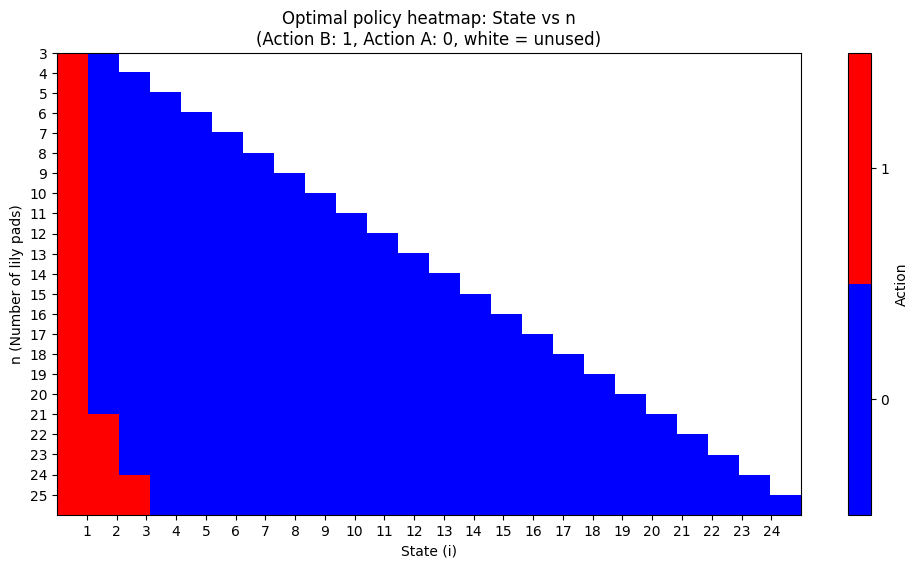

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from rl.markov_process import NonTerminal

# Collect all policies for each n
policies = []
policy_states = []
n_values = list(range(3, 26))
for n in n_values:
    mdpr = get_lily_pads_mdp(n)
    fp: MDPFrogPond = MDPFrogPond(data=mdpr['data'], gamma=mdpr['gamma'], n=n)
    opt_vf, opt_policy = value_iteration_result(fp.mdp, gamma=gamma)
    policies.append(opt_policy)
    # Make sure to sort the states
    # policy_states.append(sorted([s for s in fp.mdp.non_terminal_states] + [NonTerminal(0), NonTerminal(n)]))
    policy_states.append(sorted([s for s in fp.mdp.non_terminal_states]))



max_n = max(n_values)
policy_array = np.full((len(n_values), max_n), np.nan)

for idx, (n, opt_policy, states) in enumerate(zip(n_values, policies, policy_states)):
    for s in range(1, n):
        action = opt_policy.action_for[s] if s in opt_policy.action_for else None
        if action == 'A':
            policy_array[idx, s] = 0
        elif action == 'B':
            policy_array[idx, s] = 1
policy_array = policy_array[:, 1:]



plt.figure(figsize=(12, 6))
cmap = plt.cm.get_cmap('bwr', 2)
im = plt.imshow(policy_array, aspect='auto', cmap=cmap, vmin=0, vmax=1, 
                extent=[0, max_n, n_values[-1]+1, n_values[0]])

plt.colorbar(im, ticks=[0, 1], label="Action")
plt.clim(-0.5, 1.5)
plt.yticks(n_values)
plt.xticks(np.arange(1, max_n))
plt.xlabel("State (i)")
plt.ylabel("n (Number of lily pads)")
plt.title("Optimal policy heatmap: State vs n\n(Action B: 1, Action A: 0, white = unused)")
plt.show()



## Question 4: Manual Value Iteration (Led by ______)

Consider a simple MDP with ${S} = \{s_1, s_2, s_3\}, {T} = \{s_3\}, {A} = \{a_1, a_2\}$. The State Transition Probability function  
$${P}: {N} \times {A} \times {S} \rightarrow [0, 1]$$  
is defined as:  
$${P}(s_1, a_1, s_1) = 0.25, {P}(s_1, a_1, s_2) = 0.65, {P}(s_1, a_1, s_3) = 0.1$$  
$${P}(s_1, a_2, s_1) = 0.1, {P}(s_1, a_2, s_2) = 0.4, {P}(s_1, a_2, s_3) = 0.5$$  
$${P}(s_2, a_1, s_1) = 0.3, {P}(s_2, a_1, s_2) = 0.15, {P}(s_2, a_1, s_3) = 0.55$$  
$${P}(s_2, a_2, s_1) = 0.25, {P}(s_2, a_2, s_2) = 0.55, {P}(s_2, a_2, s_3) = 0.2$$  

The Reward Function  
$${R}: {N} \times {A} \rightarrow \mathbb{R}$$  
is defined as:  
$${R}(s_1, a_1) = 8.0, {R}(s_1, a_2) = 10.0$$  
$${R}(s_2, a_1) = 1.0, {R}(s_2, a_2) = -1.0$$ 

Assume a discount factor of $\gamma = 1$.

### Problem Statement

Your task is to determine an Optimal Deterministic Policy **by manually working out** (not with code) the first two iterations of the Value Iteration algorithm.

---

### Subquestions

#### Part (A): 2 Iterations

1. Initialize the Value Function for each state to be its $\max$ (over actions) reward, i.e., we initialize the Value Function to be $v_0(s_1) = 10.0, v_0(s_2) = 1.0, v_0(s_3) = 0.0$. Then manually calculate $q_k(\cdot, \cdot)$ and $v_k(\cdot)$ from $v_{k - 1}(\cdot)$ using the Value Iteration update, and then calculate the greedy policy $\pi_k(\cdot)$ from $q_k(\cdot, \cdot)$ for $k = 1$ and $k = 2$ (hence, 2 iterations).

---

#### Part (B): Argument

1. Now argue that $\pi_k(\cdot)$ for $k > 2$ will be the same as $\pi_2(\cdot)$. *Hint*: You can make the argument by examining the structure of how you get $q_k(\cdot, \cdot)$ from $v_{k-1}(\cdot)$. With this argument, there is no need to go beyond the two iterations you performed above, and so you can establish $\pi_2(\cdot)$ as an Optimal Deterministic Policy for this MDP.

---

#### Part (C): Policy Evaluation

1. Using the policy $\pi_2(\cdot)$, compute the exact value function $V^{\pi_2}(s)$ for all $s\in S$.

---

#### Part (D): Sensitivity Analysis

Assume the reward for $R(s_1, a_2)$ is modified to $11.0$ instead of $10.0$.

1. Perform one iteration of Value Iteration starting from the initialized value function $v_0(s)$, where $v_0(s)$ remains the same as in the original problem.
2. Determine whether this change impacts the Optimal Deterministic Policy $\pi(\cdot)$. If it does, explain why.

---

### Part (A) Answer

<span style="color:red">*fill in*</span>

### Part (B) Answer:  

<span style="color:red">*fill in*</span>

### Part (C) Answer:  

<span style="color:red">*fill in*</span>

### Part (D) Answer

#### Value Iteration:  

<span style="color:red">*fill in*</span>

#### Optimal Deterministic Policy:  

<span style="color:red">*fill in*</span>

## Question 5: Fixed-Point and Policy Evaluation True/False Questions (Led by ______)

### Recall Section: Key Formulas and Definitions

#### Bellman Optimality Equation
The Bellman Optimality Equation for state-value functions is:
$$
V^*(s) = \max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^*(s') \right].
$$
For action-value functions:
$$
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s, a, s') \max_{a'} Q^*(s', a').
$$

#### Contraction Property
The Bellman Policy Operator $B^\pi$ is a contraction under the $L^\infty$-norm:
$$
\|B^\pi(X) - B^\pi(Y)\|_\infty \leq \gamma \|X - Y\|_\infty.
$$
This guarantees convergence to a unique fixed point.

#### Policy Iteration
Policy Iteration alternates between:
1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$.
2. **Policy Improvement**: Generate a new policy $\pi'$ by setting:
   $$
   \pi'(s) = \arg\max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^\pi(s') \right].
   $$

#### Discounted Return
The discounted return from time step $t$ is:
$$
G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i,
$$
where $\gamma \in [0, 1)$ is the discount factor.

### True/False Questions (Provide Justification)

1. **True/False**: If $Q^\pi(s, a) = 5$, $P(s, a, s') = 0.5$ for $s' \in \{s_1, s_2\}$, and the immediate reward $R(s, a)$ increases by $2$, the updated action-value function $Q^\pi(s, a)$ also increases by $2$.


---

2. **True/False**: For a discount factor $\gamma = 0.9$, the discounted return for rewards $R_1 = 5, R_2 = 3, R_3 = 1$ is greater than $6$.

---

3. **True/False**: The Bellman Policy Operator $B^\pi(V) = R^\pi + \gamma P^\pi \cdot V$ satisfies the contraction property for all $\gamma \in [0, 1)$, ensuring a unique fixed point.

---

4. **True/False**: In Policy Iteration, the Policy Improvement step guarantees that the updated policy $\pi'$ will always perform strictly better than the previous policy $\pi$.

---

5. **True/False**: If $Q^\pi(s, a) = 10$ for all actions $a$ in a state $s$, then the corresponding state-value function $V^\pi(s) = 10$, regardless of the policy $\pi$.

---

6. **True/False**: The discounted return $G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i$ converges to a finite value for any sequence of bounded rewards if $\gamma < 1$.

---

### Answers (Provide justification, brief explanations are fine)

#### Question 1:  

**True**:  
   From the Bellman expectation equation,  
   $$
   Q^\pi(s,a) = R(s,a) + \gamma \sum_{s'} P(s,a,s') V^\pi(s').
   $$  
   If only the immediate reward $R(s,a)$ increases by $2$ while transition probabilities and $V^\pi$ remain unchanged, then $Q^\pi(s,a)$ increases by exactly $2$.

#### Question 2:  

**True**:  
   The discounted return is  
   $$
   G_0 = 0.9^{0}\cdot 5 + 0.9^{1}\cdot 3 + 0.9^{2}\cdot 1
       = 5 + 2.7 + 0.81
       = 8.51,
   $$  
   which is greater than $6$.

#### Question 3:  

**True**:  
   The Bellman policy operator  
   $$
   B^\pi(V) = R^\pi + \gamma P^\pi V
   $$  
   satisfies the contraction property  
   $$
   \|B^\pi(X) - B^\pi(Y)\|_\infty \le \gamma \|X - Y\|_\infty
   $$  
   for all $\gamma \in [0,1)$. By the contraction mapping theorem, this ensures convergence to a unique fixed point $V^\pi$.

#### Question 4:  

 **False**:  
   Policy improvement guarantees that the updated policy $\pi'$ is **no worse** than the previous policy $\pi$, but not necessarily strictly better. If $\pi$ is already greedy with respect to $V^\pi$ (or there are ties in the $\arg\max$), then $\pi' = \pi$ and performance does not strictly improve.

#### Question 5:  

**True**:  
   The state-value function is  
   $$
   V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s,a).
   $$  
   If $Q^\pi(s,a) = 10$ for all actions $a$, then  
   $$
   V^\pi(s) = \sum_a \pi(a \mid s)\cdot 10 = 10,
   $$  
   regardless of the policy $\pi$.

#### Question 6:  

 **True**:  
   If rewards are bounded, i.e. $|R_i| \le M$, then  
   $$
   |G_t| = \left|\sum_{i=t+1}^\infty \gamma^{i-t-1} R_i \right|
   \le \sum_{k=0}^\infty \gamma^k M
   = \frac{M}{1-\gamma},
   $$  
   which is finite for any $\gamma < 1$.